In [1]:
import os, time

import math
import numpy as np
from numpy.polynomial.hermite import hermgauss

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable 

from skrmt.ensemble.spectral_law import MarchenkoPasturDistribution

# Following options are dependant on https://github.com/chanjure/global_chanju.git
# However, this is just an aesthetic package for plotting, so it is not necessary.
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten


set_rc() # Setting global chanju plotting scheme

In [2]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=200):
    new_cmap = LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [3]:
def simulate(epsilon, sigma, N, M, n_try, n_data, f, fp, data_dir):
    
    r = N/M
    
    # Load or generate data
    data_string = "N%d_r%.2f_eps%.5f_sig%.5f"%(N, r, epsilon, sigma)
    print(data_string)

    if data_string+"_data.npz" in os.listdir(data_dir):
        load = True
        print("Load data from "+data_dir+data_string+"_data.npz")
    else:
        load = False

    W_star = np.zeros((N, M))
    W_star[0][0] = 1
    README = ""

    if load:
        data = np.load(data_dir+data_string+"_data.npz")
        README = data["README"]
        W_list = data["W_list"]
        l_list = data["l_list"]
        dl_list = data["dl_list"]

        print("Data loaded from: "+data_dir+data_string+"_data.npz")
    else:
        print("=====")
        print("Generating ... ")
        W_list = np.zeros((n_try, 2, N, M))
        l_list = np.zeros((n_try, 2))
        dl_list = np.zeros((n_try))

        for n in range(n_try):
            data = np.random.normal(0., 1., size=(n_data, M))
            W0 = np.random.normal(0., sigma/np.sqrt(M), size=(N, M))

            W_list[n][0] = W0.copy()

            h_hat = data @ W0.T # n x M

            y_hat = f(h_hat) # n x M
            y = f(data @ W_star.T) # n x M

            l_ = 0.5*np.trace((y - y_hat) @ (y - y_hat).T)/n_data

            l_list[n][0] = l_.copy()

            dl = - np.mean(np.einsum("nM, nN, nN -> nNM", 
                                     data, y - y_hat, fp(h_hat)), 
                           axis=0)
            
            dl_list[n] = np.linalg.norm(dl)

            # Single Step Update
            W_ = W0 - epsilon * dl

            W_list[n][1] = W_.copy()

            h_hat = data @ W_.T # n x M

            y_hat = f(h_hat) # n x M
            y = f(data @ W_star.T) # n x M

            l_ = 0.5*np.trace((y - y_hat) @ (y - y_hat).T)/n_data

            l_list[n][1] = l_.copy()

        # Generate the docstring
        README = """
        N: %d
        M: %d
        r: %.4f
        eps: %.4f
        sig: %.4f
        n_try: %d
        """%(N, M, r, epsilon, sigma, n_try)

        np.savez(data_dir+data_string+"_data.npz",
                 README = README,
                 W_list = W_list, 
                 l_list = l_list,
                 dl_list = dl_list,
                )

        print("Data saved to "+data_dir+data_string+"_data.npz")
        print(README)
        print("=====")

In [4]:
def calculate_dx(epsilon, sigma, data_dir):
    # Load or generate data
    data_string = "N%d_r%.2f_eps%.5f_sig%.5f"%(N, r, epsilon, sigma)
    print("Loading " + data_string)

    with np.load(data_dir+data_string+"_data.npz") as data:
        W_list = data["W_list"][:, 1]

    Xp = np.einsum("nNM, nLM -> nNL", W_list, W_list)
    x, u = np.linalg.eig(Xp)
       
    diff = (x[:, 0] - x[:, 1]) / x[:, 0]
    q2_ = u[:, 0, 0]**2
    
    u_ab = []
    
    w_vec = W_list.reshape(len(W_list), -1)
    w_norm = w_vec / np.linalg.norm(w_vec, axis=-1, keepdims=True)
    w_ab = []
    
    for i in range(u.shape[0]):
        for j in range(i+1, u.shape[0]):
            u_ab.append((np.sum(u[i, 0] * u[j, 0], axis=-1))**2)
            w_ab.append(np.abs(np.sum(w_norm[i] * w_norm[j], axis=-1)))
            
    u_ab = np.array(u_ab)
    w_ab = np.array(w_ab)
    
    W_star = np.zeros_like(W_list)
    W_star[:, 0, 0] = 1
    w_star = W_star.reshape(len(W_list), -1)
    w_st = np.sum(w_norm*w_star, axis=-1)**2

    return diff, q2_, u_ab, w_ab, w_st

# 2. Non-linear models

\begin{align}
    \mu_{1,a} &= \mathbb{E}_{x} \left[\sigma'(h_a^{\ast}) \sigma'(h_a) \right]\, , \\
    \mu_{2,a} &= \mathbb{E}_{x} \left[(\sigma'(h_a))^2 + (\sigma (h_a) - \sigma (h_a^{\ast})) \sigma''(h_a) \right] \, .
\end{align}

\begin{align}
    \epsilon_0 = \frac{\mu_{2,a} + \mu_{2, b}}{2 \mu_{2,a} \mu_{2,b}}
    \simeq \frac{1}{\mu_2}
\end{align}

In [5]:
def tanhp(x):
    return np.ones_like(x) - np.tanh(x)**2

def tanhpp(x):
    return 2.*np.tanh(x)**3 - 2.*np.tanh(x)

def relu(x):
    return np.maximum(x, 0, x)

def relup(x):
    return np.heaviside(x, x)

def relupp(x):
#     return np.zeros_like(x)
    eps = 1e-8 * np.ones_like(x)
    return np.where(np.abs(x) > eps, 0., 1./eps)

In [6]:
def mu_gausshermite(sigma, f, fp, fpp):
    """ Integrate mu using Gauss Hermite integration
    """
    print("mu %.5e"%(sigma))

    nodes, weights = hermgauss(300)
    
    ht = np.sqrt(2) * nodes
    h = np.sqrt(2) * sigma * nodes
    
    X1, X2 = np.meshgrid(ht, h, indexing='ij')
    W = np.outer(weights, weights)
    
    mu1 = fp(ht)*fp(h)
    mu2 = fp(h)**2 + (f(h) - f(ht)) * fpp(h)
    
    return np.sum(W * mu1)/np.pi, np.sum(W * mu2)/np.pi

def epsilon_c(sigma, r, f=None, fp=None, fpp=None):
    """
    ==========
    \epsilon_c
    ==========
    
    BBP transition critical signal strength
    
    Parameters:
    ----------
    n (int): Number of samples
    L, N, M (int): Layer widths
    f (function): Activation function
    fp (function): Derivative of the activation function
    fqq (function): Second derivative of the activation function
    
    Return:
    ----------
    Three arrays \epsilon_c, \mu_1 and \mu_2, each of size n
    ==========
    """
    mu1, mu2 = mu_gausshermite(sigma, f=f, fp=fp, fpp=fpp)
    eps_c_p = 1./(mu2 + mu1/(sigma * r**(0.25)))
    eps_c_n = np.where(1./(mu2 - mu1/(sigma * r**(0.25)))>0, 1./(mu2 + mu1/(sigma * r**(0.25))), np.nan)
            
    return eps_c_p, eps_c_n, mu1, mu2

def A(epsilon):
    """ Variance rescaling
    """
    return (1 - epsilon)**(2*t)

def B(epsilon):
    """ Signal rescaling
    """
    return (1 - (1 - epsilon)**t)**2

def lambda_iso(epsilon, sigma, r, f, fp, fpp):
    _, mu1, mu2 = epsilon_c(sigma, f=f, fp=fp, fpp=fpp)
    a = A(epsilon*mu2)
    b = B(epsilon*mu1)
    
    return (r * a * sigma**2 + b)*(a * sigma**2 + b) / b

## Hyperbolic tangent

In [7]:
plot_dir2 = "../images/1.non-linear/tanh/"
data_dir2 = "../data/1.non-linear/tanh/"
# data_dir2 = "../data/test/"

os.system("mkdir -p " + plot_dir2)
os.system("mkdir -p " + data_dir2)

0

In [8]:
n_x = 500 # number of sigma points
sig_list = np.logspace(-2, 2, n_x) # Same sigma range as in phase transition paper

r = 0.5

actf = "tanh"
# actf = "relu"

if actf == "tanh":
    f = np.tanh
    fp = tanhp
    fpp = tanhpp
    
elif actf == "relu":
    f = relu
    fp = relup
    fpp = relupp
    
else:
    raise ValueError("Wrong Activation")
    
figure_id = "top_eig_diff_exp"
    

try:
    with np.load(data_dir2+actf+"_"+figure_id+".npz") as data:
        epsilon_c_list = data["epsilon_c_list"]
        epsilon_c_n_list = data["epsilon_c_n_list"]
        mu1_list = data["mu1_list"]
        mu2_list = data["mu2_list"]
        
    print("Loaded the figure from "+data_dir2+"fig_"+figure_id+".npz")
    
except:
    now = time.time()

    data_list = np.array(list(map(lambda x: epsilon_c(x, 
                                                      r=r,
                                                      f=f, 
                                                      fp=fp, 
                                                      fpp=fpp), 
                                  sig_list)))

    epsilon_c_list = data_list[:, 0]
    epsilon_c_n_list = data_list[:, 1]
    mu1_list = data_list[:,2]
    mu2_list = data_list[:,3]

    print("total elapsed:", time.strftime("%H:%M:%S", time.gmtime(time.time() - now)))

    np.savez(data_dir2+actf+"_"+figure_id+".npz", 
             epsilon_c_list = epsilon_c_list,
             epsilon_c_n_list = epsilon_c_n_list,
             mu1_list = mu1_list,
             mu2_list = mu2_list
            )
    print("Saved the figure to "+data_dir2+actf+"_"+figure_id+".npz")

Loaded the figure from ../data/1.non-linear/tanh/fig_top_eig_diff_exp.npz


In [9]:
# Generate single step trained networks
# The size of the generated data is a bit large, I will share it with you via email if you want.

N = 100
M = 200
r = N/M

n_try = 5
n_data = 3000

epsilon_list = np.logspace(-2, 2, 10)
sigma_list = np.logspace(-2, 2, 10)

for epsilon in epsilon_list:
    for sigma in sigma_list:
        simulate(epsilon, sigma, 
                 N=N, M=M, 
                 n_try=n_try, 
                 n_data=n_data, 
                 f=f, fp=fp, 
                 data_dir=data_dir2)
        
print("done")

N100_r0.50_eps0.01000_sig0.01000
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.01000_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.01000_data.npz
N100_r0.50_eps0.01000_sig0.02783
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.02783_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.02783_data.npz
N100_r0.50_eps0.01000_sig0.07743
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.07743_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.07743_data.npz
N100_r0.50_eps0.01000_sig0.21544
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.21544_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.21544_data.npz
N100_r0.50_eps0.01000_sig0.59948
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.59948_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.01000_sig0.59948

Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig0.01000_data.npz
N100_r0.50_eps0.59948_sig0.02783
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig0.02783_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig0.02783_data.npz
N100_r0.50_eps0.59948_sig0.07743
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig0.07743_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig0.07743_data.npz
N100_r0.50_eps0.59948_sig0.21544
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig0.21544_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig0.21544_data.npz
N100_r0.50_eps0.59948_sig0.59948
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig0.59948_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig0.59948_data.npz
N100_r0.50_eps0.59948_sig1.66810
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps0.59948_sig1.66810

Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps35.93814_sig0.02783_data.npz
N100_r0.50_eps35.93814_sig0.07743
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps35.93814_sig0.07743_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps35.93814_sig0.07743_data.npz
N100_r0.50_eps35.93814_sig0.21544
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps35.93814_sig0.21544_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps35.93814_sig0.21544_data.npz
N100_r0.50_eps35.93814_sig0.59948
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps35.93814_sig0.59948_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps35.93814_sig0.59948_data.npz
N100_r0.50_eps35.93814_sig1.66810
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps35.93814_sig1.66810_data.npz
Data loaded from: ../data/1.non-linear/tanh/N100_r0.50_eps35.93814_sig1.66810_data.npz
N100_r0.50_eps35.93814_sig4.64159
Load data from ../data/1.non-linear/tanh/N100_r0.50_eps35.9

In [10]:
try:
    with np.load(data_dir2+"q2_diff_measure.npz") as data:
        diff_list = data["diff_list"]
        diff_err_list = data["diff_err_list"]
        q2_list = data["q2_list"]
        q2_err_list = data["q2_err_list"]
        u_ab_list = data["u_ab_list"]
        u_ab_err_list = data["u_ab_err_list"]
        w_ab_list = data["w_ab_list"]
        w_ab_err_list = data["w_ab_err_list"]
        w_st_list = data["w_st_list"]
        w_st_err_list = data["w_st_err_list"]
        
    print("Load from "+data_dir2 +"q2_diff_measure.npz")
        
except:
    diff_list = np.zeros((len(sigma_list), len(epsilon_list)))
    diff_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

    q2_list = np.zeros((len(sigma_list), len(epsilon_list)))
    q2_err_list = np.zeros((len(sigma_list), len(epsilon_list)))
    
    u_ab_list = np.zeros((len(sigma_list), len(epsilon_list)))
    u_ab_err_list = np.zeros((len(sigma_list), len(epsilon_list)))
    
    w_ab_list = np.zeros((len(sigma_list), len(epsilon_list)))
    w_ab_err_list = np.zeros((len(sigma_list), len(epsilon_list)))
    
    w_st_list = np.zeros((len(sigma_list), len(epsilon_list)))
    w_st_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

    for i, epsilon in enumerate(epsilon_list):
        for j, sigma in enumerate(sigma_list):
            diff, q2, u_ab, w_ab, w_st = calculate_dx(epsilon, sigma, data_dir2)

            diff_list[j, i] = np.mean(diff, axis=0)
            diff_err_list[j, i] = np.std(diff, axis=0)

            q2_list[j, i] = np.mean(q2, axis=0)
            q2_err_list[j, i] = np.std(q2, axis=0)  
            
            u_ab_list[j, i] = np.mean(u_ab, axis=0)
            u_ab_err_list[j, i] = np.std(u_ab, axis=0)
            
            w_ab_list[j, i] = np.mean(w_ab, axis=0)
            w_ab_err_list[j, i] = np.std(w_ab, axis=0)
            
            w_st_list[j, i] = np.mean(w_st, axis=0)
            w_st_err_list[j, i] = np.std(w_st, axis=0)
            
    np.savez(data_dir2+"q2_diff_measure.npz",
             diff_list = diff_list,
             diff_err_list = diff_err_list,
             q2_list = q2_list,
             q2_err_list = q2_err_list,
             u_ab_list = u_ab_list,
             u_ab_err_list = u_ab_err_list,
             w_ab_list = w_ab_list,
             w_ab_err_list = w_ab_err_list,
             w_st_list = w_st_list,
             w_st_err_list = w_st_err_list
            )
    
    print("Saved to "+data_dir2 +"q2_diff_measure.npz")

print("done")

Load from ../data/1.non-linear/tanh/q2_diff_measure.npz
done


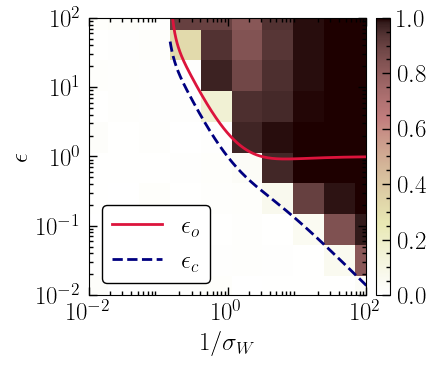

In [11]:
cmap = plt.get_cmap('pink_r')
new_cmap = truncate_colormap(cmap, 0.0, 1.)

set_rc(scale=1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, q2_list.T,
                    vmin=0, vmax=1,
#                     cmap='pink_r',
                    cmap=cmap,
                    shading='auto')

mu2_valid = np.where(mu2_list >= 0, mu2_list, np.nan)
axs.plot(1./sig_list, 1./mu2_valid, 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

epsilon_c_valid = np.where(mu2_list >= 0, epsilon_c_list, np.nan)
axs.plot(1./sig_list, epsilon_c_valid,
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sig_list, epsilon_c_n_list,
         color='navy', marker='', ls='--', lw=2,)

plt.legend(loc='lower left', facecolor='white', frameon=True, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir2 + actf + "_" + "q2_exp.pdf", bbox_inches="tight")

plt.show()

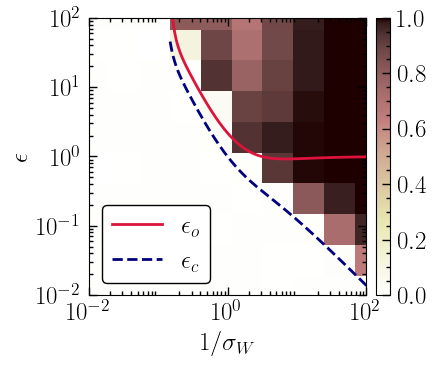

In [12]:
cmap = plt.get_cmap('pink_r')
new_cmap = truncate_colormap(cmap, 0.0, 1.)

set_rc(scale=1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, u_ab_list.T,
                    vmin=0, vmax=1,
#                     cmap='pink_r',
                    cmap=cmap,
                    shading='auto')

mu2_valid = np.where(mu2_list > 0, mu2_list, np.nan)
axs.plot(1./sig_list, 1./mu2_valid, 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

epsilon_c_valid = np.where(mu2_list > 0, epsilon_c_list, np.nan)
axs.plot(1./sig_list, epsilon_c_valid,
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sig_list, epsilon_c_n_list,
         color='navy', marker='', ls='--', lw=2,)

plt.legend(loc='lower left', facecolor='white', frameon=True, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir2 + actf + "_" + "u_ab_exp.pdf", bbox_inches="tight")

plt.show()

In [13]:
def calculate_dx_last(epsilon, sigma, data_dir, epoch=-1):
    # Load or generate data
    data_string = "dyn_N%d_r%.2f_eps%.5f_sig%.5f"%(N, r, epsilon, sigma)
    print("Loading " + data_string)

    with np.load(data_dir+data_string+"_data.npz") as data:
        W_list = data["W_list"][:, -1]

    Xp = np.einsum("nNM, nLM -> nNL", W_list, W_list)
    n = len(Xp)
    
    try:
        x, u = np.linalg.eig(Xp)
       
        diff = (x[:, 0] - x[:, 1]) / x[:, 0]
        q2_ = u[:, 0, 0]**2

        u_ab = []

        w_vec = W_list.reshape(len(W_list), -1)
        w_norm = w_vec / np.linalg.norm(w_vec, axis=-1, keepdims=True)
        w_ab = []

        for i in range(u.shape[0]):
            for j in range(i+1, u.shape[0]):
                u_ab.append(np.abs(np.sum(u[i, 0] * u[j, 0], axis=-1)))
                w_ab.append(np.abs(np.sum(w_norm[i] * w_norm[j], axis=-1)))

        u_ab = np.array(u_ab)
        w_ab = np.array(w_ab)
    
        W_star = np.zeros_like(W_list)
        W_star[:, 0, 0] = 1
        w_star = W_star.reshape(len(W_list), -1)
        w_st = np.sum(w_norm*w_star, axis=-1)**2
        
    except:
        diff = np.nan * np.ones((n))
        q2_ = np.nan * np.ones((n))
        u_ab = np.nan * np.ones(int(n*(n-1)/2))
        w_ab = np.nan * np.ones(int(n*(n-1)/2))
        w_st = np.nan * np.ones(int(n))

    return diff, q2_, u_ab, w_ab, w_st

In [14]:
epoch_list = [50, 100, 200]

q2_time = []

for epoch in epoch_list:
    data_dir = data_dir2+"epoch%d/"%(epoch)

    epsilon_list = np.logspace(-2, 2, 10)
    sigma_list = np.logspace(-2, 2, 10)

    try:
        with np.load(data_dir+"dyn_q2_diff_measure.npz") as data:
            diff_list = data["diff_list"]
            diff_err_list = data["diff_err_list"]
            q2_list_last = data["q2_list"]
            q2_err_list = data["q2_err_list"]
            u_ab_list = data["u_ab_list"]
            u_ab_err_list = data["u_ab_err_list"]
            w_ab_list = data["w_ab_list"]
            w_ab_err_list = data["w_ab_err_list"]
            w_st_list = data["w_st_list"]
            w_st_err_list = data["w_st_err_list"]

        print("Load from "+data_dir +"dyn_q2_diff_measure.npz")

    except:
        diff_list = np.zeros((len(sigma_list), len(epsilon_list)))
        diff_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        q2_list_last = np.zeros((len(sigma_list), len(epsilon_list)))
        q2_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        u_ab_list = np.zeros((len(sigma_list), len(epsilon_list)))
        u_ab_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        w_ab_list = np.zeros((len(sigma_list), len(epsilon_list)))
        w_ab_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        w_st_list = np.zeros((len(sigma_list), len(epsilon_list)))
        w_st_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        for i, epsilon in enumerate(epsilon_list):
            for j, sigma in enumerate(sigma_list):
                diff, q2_, u_ab, w_ab, w_st = calculate_dx_last(epsilon, sigma, data_dir, epoch=epoch)

                diff_list[j, i] = np.mean(diff, axis=0)
                diff_err_list[j, i] = np.std(diff, axis=0)

                q2_list_last[j, i] = np.mean(q2_, axis=0)
                q2_err_list[j, i] = np.std(q2_, axis=0)  

                u_ab_list[j, i] = np.mean(u_ab, axis=0)
                u_ab_err_list[j, i] = np.std(u_ab, axis=0)

                w_ab_list[j, i] = np.mean(w_ab, axis=0)
                w_ab_err_list[j, i] = np.std(w_ab, axis=0)

                w_st_list[j, i] = np.mean(w_st, axis=0)
                w_st_err_list[j, i] = np.std(w_st, axis=0)

        np.savez(data_dir+"dyn_q2_diff_measure.npz",
                 diff_list = diff_list,
                 diff_err_list = diff_err_list,
                 q2_list = q2_list_last,
                 q2_err_list = q2_err_list,
                 u_ab_list = u_ab_list,
                 u_ab_err_list = u_ab_err_list,
                 w_ab_list = w_ab_list,
                 w_ab_err_list = w_ab_err_list,
                 w_st_list = w_st_list,
                 w_st_err_list = w_st_err_list
                )

        print("Saved to "+data_dir +"dyn_q2_diff_measure.npz")

    print("done")
    
    q2_time.append(q2_list_last)
    
q2_time = np.array(q2_time)

Load from ../data/1.non-linear/tanh/epoch50/dyn_q2_diff_measure.npz
done
Load from ../data/1.non-linear/tanh/epoch100/dyn_q2_diff_measure.npz
done
Load from ../data/1.non-linear/tanh/epoch200/dyn_q2_diff_measure.npz
done


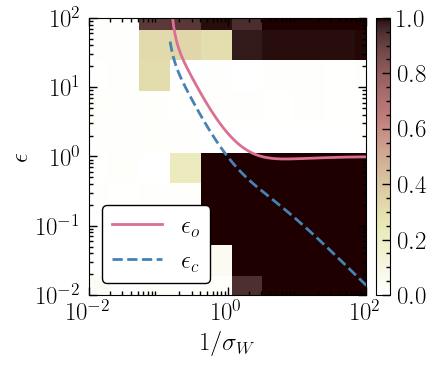

In [15]:
cmap = plt.get_cmap('pink_r')
new_cmap = truncate_colormap(cmap, 0.0, 1.)

set_rc(scale=1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, q2_list_last.T,
                    vmin=0, vmax=1,
#                     cmap='pink_r',
                    cmap=cmap,
                    shading='auto')

mu2_valid = np.where(mu2_list >= 1e-12, mu2_list, np.nan)
axs.plot(1./sig_list, 1./mu2_valid, 
         color='palevioletred', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

epsilon_c_valid = np.where(mu2_list >= 1e-12, epsilon_c_list, np.nan)
axs.plot(1./sig_list, epsilon_c_valid,
         color='steelblue', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")

plt.legend(loc='lower left', facecolor='white', frameon=True, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir2 + actf + "_" + "q2_exp_last%d.pdf"%(epoch), bbox_inches="tight")

plt.show()

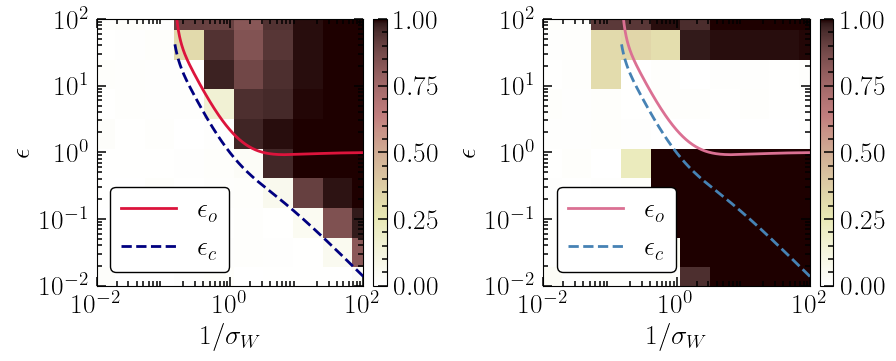

In [16]:
set_rc(scale=1.1)
n_fig = 2

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

im = axs[0].pcolormesh(
    1./X, Y, q2_list.T,
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

mu2_valid = np.where(mu2_list >= 0, mu2_list, np.nan)
# Optimal epsilon
axs[0].plot(
    1./sig_list, 1./mu2_valid, 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
epsilon_c_valid = np.where(mu2_list > 0, epsilon_c_list, np.nan)
axs[0].plot(
    1./sig_list, epsilon_c_valid, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)

axs[0].legend(
    loc='lower left', 
    facecolor='white', 
    frameon=True, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[0], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[0].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)


# Experimental phase diagram
im = axs[1].pcolormesh(
    1./X, Y, q2_list_last.T,
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
axs[1].plot(
    1./sig_list, 1./mu2_valid, 
    color='palevioletred', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
axs[1].plot(
    1./sig_list, epsilon_c_valid, 
    color='steelblue', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)

axs[1].legend(
    loc='lower left', 
    facecolor='white', 
    frameon=True, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[1], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[1].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir2 + "tanh_exp_all.pdf", bbox_inches="tight")

plt.show()

/opt/miniconda3/envs/work/lib/python3.9/site-packages/global_chanju/paulplot/styles.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.tight_layout()
/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_9481/703876061.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


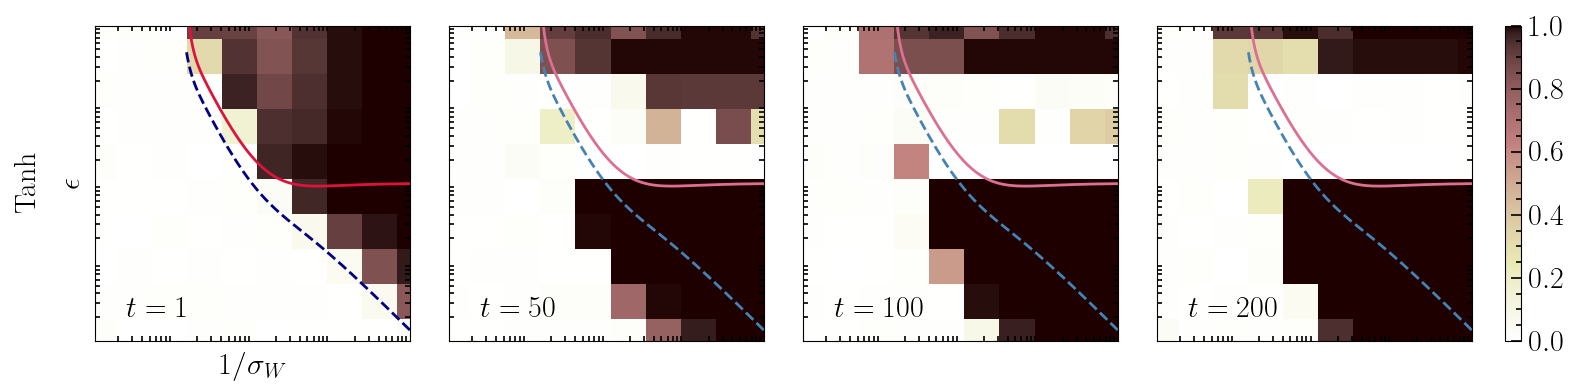

In [17]:
from matplotlib.gridspec import GridSpec

set_rc(scale=1.2)
n_fig = 5

fig = plt.figure(
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

gs = GridSpec(
    1, 5,
    width_ratios=[0.1, 1, 1, 1, 1],
    wspace=0.4
)

ax_title = fig.add_subplot(gs[0, 0])
ax_title.axis("off")

ax_title.text(
    0.5, 0.5,
    "Tanh",
    rotation=90,
    va='center',
    ha='center',
#     fontsize=16
)

axes = []
pcm = None

# Initial
ax = fig.add_subplot(gs[0, 1])

pcm = ax.pcolormesh(
    1./X, Y, 
    q2_list.T,
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

mu2_valid = np.where(mu2_list > 0, mu2_list, np.nan)
epsilon_c_valid = np.where(mu2_list > 0, epsilon_c_list, np.nan)

# Optimal epsilon
ax.plot(
    1./sig_list, 1./mu2_valid, 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
ax.plot(
    1./sig_list, epsilon_c_valid, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
ax.plot(
    1./sig_list, epsilon_c_n_list, 
    color='navy', marker='', ls='--', lw=2,
)

ax.text(
    0.1, 0.1,
    transform=ax.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"$t=1$"
)

nice_style(
    ax, 
    ylim=(1e-2, 1e2),
    xlim=(1e-2, 1e2),
        xlabel=r"$1/\sigma_W$",
        ylabel=r"$\epsilon$",
    logx=True, logy=True,
    xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
)

ax.set_aspect('equal')

axes.append(ax)

for i, epoch in enumerate(epoch_list):
    ax = fig.add_subplot(gs[0, i+2])

    pcm = ax.pcolormesh(
        1./X, Y, 
        q2_time[i].T,
        vmin=0, vmax=1,
        cmap='pink_r',
        shading='auto'
    )
    
    # Optimal epsilon
    ax.plot(
        1./sig_list, 1./mu2_valid, 
        color='palevioletred', marker='', ls='-', lw=2, 
        label=r"$\epsilon_o$"
    )

    # Critical step size
    ax.plot(
        1./sig_list, epsilon_c_valid, 
        color='steelblue', marker='', ls='--', lw=2,
        label=r"$\epsilon_c$"
    )
    ax.plot(
        1./sig_list, epsilon_c_n_list, 
        color='steelblue', marker='', ls='--', lw=2,
    )

    ax.text(
        0.1, 0.1,
        transform=ax.transAxes,
        horizontalalignment='left', verticalalignment='center',
        color='k', 
        s=r"$t=%d$"%(epoch)
    )

    nice_style(
        ax, 
        ylim=(1e-2, 1e2),
        xlim=(1e-2, 1e2),
        logx=True, logy=True,
        xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
    )
    
    ax.set_aspect('equal')

    axes.append(ax)

    
cbar = fig.colorbar(
    pcm,
    ax=axes,
    location='right',
    shrink=0.77,
    pad=0.02
)

plt.tight_layout()

plt.savefig(plot_dir2+"tanh_q2_time_dep.pdf")

plt.show()